# 第1回 — PyTorch 超入門 + データを触る

このノートブックは KWS（keyword spotting）チュートリアルの第1回．題材は torchaudio の
`SPEECHCOMMANDS`（35 クラスの音声コマンド認識）．

**今日のゴール**: `DataLoader` を回すと **log-mel スペクトログラムのミニバッチ `(B, 1, n_mels, T)`** が
出てくるのを，自分の手で動かして確認する．

進め方: 上から順にセルを実行し，説明を読みつつ **`# TODO` のセルを埋めて**動かす．
最後に，埋めたコードを `src/kws/data.py` に整理する．

> 参考: PyTorch 公式 "Learn the Basics" / Datasets & DataLoaders
> https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html

In [1]:
# プロジェクトルートで動かす前提（notebooks/ から開いても data/ や exp/ を相対参照できるように）
import os
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
print("cwd:", Path.cwd())

cwd: /home/ymgt/ShiotaLab/B4_rinko_torchaudio


## 0. 環境構築（uv）— 各自ターミナルで実施済みの想定

この教材は `uv` でゼロから環境を作れる．授業前に済ませておく:

```bash
# プロジェクト作成と依存追加（CUDA は cu121 の例．GPU に合わせて変える）
uv init
uv add torch torchaudio --index https://download.pytorch.org/whl/cu121
uv add matplotlib soundfile pyyaml scikit-learn tqdm wandb ipykernel
# 既に pyproject.toml がある場合は: uv sync
```

下のセルで torch が入っていて GPU が見えることを確認する．

In [2]:
import torch
import torchaudio
print("torch:", torch.__version__)
print("torchaudio:", torchaudio.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device name:", torch.cuda.get_device_name(0))

torch: 2.4.1+cu121
torchaudio: 2.4.1+cu121
CUDA available: True
device name: NVIDIA GeForce RTX 2080 Ti


## 1. Tensor と autograd の超入門

PyTorch の主役は **Tensor**（多次元配列）．NumPy 配列に似ているが，**GPU に載る**のと
**勾配を自動計算できる（autograd）**のが違い．

まずは `shape`（形）・`dtype`（型）・`device`（CPU/GPU）を意識する癖をつける．

In [3]:
x = torch.tensor([[1.0, 2.0, 3.0],
                  [4.0, 5.0, 6.0]])
print("x =", x)
print("shape:", x.shape, "| dtype:", x.dtype, "| device:", x.device)

# 演算はNumPyっぽく書ける
print("x.mean():", x.mean().item())
print("x + 10:\n", x + 10)

# device を揃えるのが鉄則（モデルとデータは同じ device に置く）
dev = "cuda" if torch.cuda.is_available() else "cpu"
x_gpu = x.to(dev)
print("moved to:", x_gpu.device)

x = tensor([[1., 2., 3.],
        [4., 5., 6.]])
shape: torch.Size([2, 3]) | dtype: torch.float32 | device: cpu
x.mean(): 3.5
x + 10:
 tensor([[11., 12., 13.],
        [14., 15., 16.]])
moved to: cuda:0


### autograd の考え方
`requires_grad=True` を付けた Tensor で計算すると，PyTorch が計算グラフを覚えていて，
`.backward()` を呼ぶと **勾配が自動で `.grad` に入る**．学習＝この勾配でパラメータを更新すること．

例: `y = (w*3 + 1)^2` の `w=2` での微分．手計算では `dy/dw = 2*(w*3+1)*3 = 2*7*3 = 42`.

In [4]:
w = torch.tensor(2.0, requires_grad=True)
y = (w * 3 + 1) ** 2
y.backward()          # 勾配を計算
print("y =", y.item())
print("dy/dw =", w.grad.item(), "（手計算の 42 と一致するはず）")

y = 49.0
dy/dw = 42.0 （手計算の 42 と一致するはず）


## 2. SPEECHCOMMANDS データセット

`torchaudio.datasets.SPEECHCOMMANDS` は1秒程度の音声コマンド（"yes","no","up",...）35クラス．
`subset` で training / validation / testing を選べる．ここでは軽い **validation** で中身を見る．

1サンプルは `(waveform, sample_rate, label, speaker_id, utterance_number)` のタプル．

In [5]:
import torchaudio
os.makedirs("data", exist_ok=True)  # torchaudio は root 自体は作らないので用意
ds = torchaudio.datasets.SPEECHCOMMANDS(root="data", download=True, subset="validation")
print("num samples (validation):", len(ds))

waveform, sr, label, *_ = ds[0]
print("waveform shape:", waveform.shape, "| sample_rate:", sr, "| label:", label)

num samples (validation): 9981
waveform shape: torch.Size([1, 15018]) | sample_rate: 16000 | label: right


### 波形とラベル分布を見る

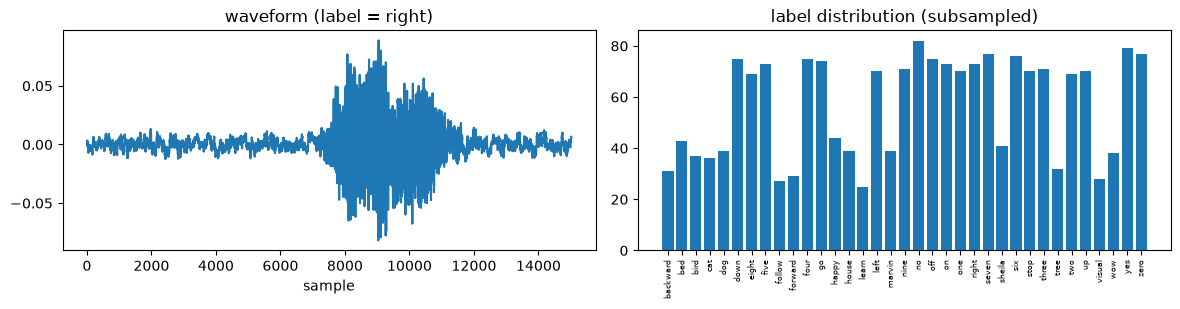

In [6]:
import matplotlib.pyplot as plt
from collections import Counter

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.2))
ax1.plot(waveform.squeeze().numpy())
ax1.set_title(f"waveform (label = {label})")
ax1.set_xlabel("sample")

labels = [ds[i][2] for i in range(0, len(ds), 5)]  # 間引いて集計
cnt = Counter(labels)
keys = sorted(cnt)
ax2.bar(range(len(keys)), [cnt[k] for k in keys])
ax2.set_xticks(range(len(keys)))
ax2.set_xticklabels(keys, rotation=90, fontsize=6)
ax2.set_title("label distribution (subsampled)")
fig.tight_layout()
plt.show()

## 3. ラベル ↔ index の対応

クロスエントロピー損失はラベルを **整数 index** で受け取る．35 クラスを固定順で並べて
`label_to_index` / `index_to_label` を作る．順序を固定すると環境に依らず再現できる．

In [7]:
LABELS = [
    "backward", "bed", "bird", "cat", "dog", "down", "eight", "five", "follow", "forward",
    "four", "go", "happy", "house", "learn", "left", "marvin", "nine", "no", "off",
    "on", "one", "right", "seven", "sheila", "six", "stop", "three", "tree", "two",
    "up", "visual", "wow", "yes", "zero",
]
label_to_index = {label: i for i, label in enumerate(LABELS)}
index_to_label = {i: label for i, label in enumerate(LABELS)}
print("num classes:", len(LABELS))
print("yes ->", label_to_index["yes"], "| 0 ->", index_to_label[0])

num classes: 35
yes -> 33 | 0 -> backward


## 4. 長さを揃える（pad / trim）と collate_fn

波形は長さがバラバラ．ミニバッチを1つの `(B, T)` テンソルに **stack** するには長さを揃える必要がある．
ここでは 1 秒 = 16000 サンプルに固定（短ければ 0 埋め，長ければ切り詰め）．

まず `pad_or_trim` を書く．

In [8]:
SAMPLE_RATE = 16000
NUM_SAMPLES = 16000  # 1 秒ぶん

In [9]:
import torch

def pad_or_trim(waveform: torch.Tensor, num_samples: int = NUM_SAMPLES) -> torch.Tensor:
    n = waveform.shape[-1]
    if n < num_samples:
        waveform = torch.nn.functional.pad(waveform, (0, num_samples - n))  # 末尾を 0 埋め
    elif n > num_samples:
        waveform = waveform[..., :num_samples]                              # 先頭を切り出し
    return waveform

# 確認: 短い・長い波形どちらも 16000 になる
print(pad_or_trim(torch.zeros(8000)).shape)
print(pad_or_trim(torch.zeros(20000)).shape)

torch.Size([16000])
torch.Size([16000])


## 5. log-mel スペクトログラム

波形そのままでなく **log-mel スペクトログラム**（時間×周波数の「画像」）に変換して 2D-CNN に入れる．
`MelSpectrogram`（メルスケールのパワー）→ `AmplitudeToDB`（dB = log）の2段で作る．

> 特徴量変換は **前処理側（data.py）** に置く方針．モデルは分類器に専念する．

log-mel shape: torch.Size([1, 64, 101])


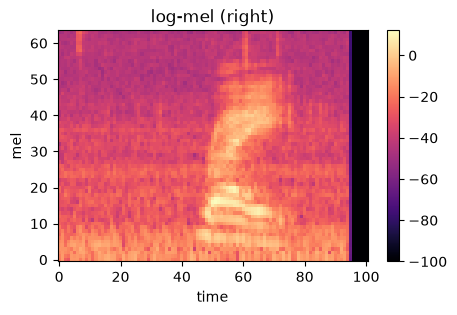

In [10]:
import torchaudio.transforms as T
from torch import nn

def make_logmel(sample_rate: int = SAMPLE_RATE, n_mels: int = 64) -> nn.Module:
    return nn.Sequential(
        T.MelSpectrogram(sample_rate=sample_rate, n_fft=400, hop_length=160, n_mels=n_mels),
        T.AmplitudeToDB(),
    )

logmel = make_logmel(n_mels=64)
spec = logmel(pad_or_trim(waveform.squeeze(0)).unsqueeze(0))  # (1, n_mels, T')
print("log-mel shape:", spec.shape)

plt.figure(figsize=(5, 3))
plt.imshow(spec.squeeze(0).numpy(), origin="lower", aspect="auto", cmap="magma")
plt.title(f"log-mel ({label})"); plt.xlabel("time"); plt.ylabel("mel"); plt.colorbar()
plt.show()

## 6. collate_fn でミニバッチを作る

`DataLoader` は `collate_fn` で「サンプルのリスト → バッチテンソル」に変換する．
ここで **1) 長さ揃え → 2) stack → 3) log-mel → 4) ラベルを index 化** を行う．

In [11]:
def make_collate_fn(transform: nn.Module):
    def collate(batch):
        waveforms, targets = [], []
        for waveform, _sr, label, *_ in batch:
            waveforms.append(pad_or_trim(waveform.squeeze(0)))  # (T,)
            targets.append(label_to_index[label])
        waveforms = torch.stack(waveforms)          # (B, T)
        feats = transform(waveforms).unsqueeze(1)   # (B, 1, n_mels, T')
        targets = torch.tensor(targets, dtype=torch.long)
        return feats, targets
    return collate

## 7. DataLoader を回す → 今日のゴール

`DataLoader` に `collate_fn` を渡して 1 バッチ取り出し，**`(B, 1, n_mels, T)`** が出ることを確認する．

> notebook では `num_workers=0`（マルチプロセスを使わない）にしておくと安定する．

In [12]:
from torch.utils.data import DataLoader

collate = make_collate_fn(make_logmel(n_mels=64))
loader = DataLoader(ds, batch_size=16, shuffle=True, num_workers=0, collate_fn=collate)

feats, targets = next(iter(loader))
print("feats:", feats.shape, feats.dtype)   # -> (16, 1, 64, 101)
print("targets:", targets.shape, targets.dtype, "| 例:", targets[:8].tolist())
print("\nゴール達成: log-mel のミニバッチ (B,1,n_mels,T) が出た！")

feats: torch.Size([16, 1, 64, 101]) torch.float32
targets: torch.Size([16]) torch.int64 | 例: [18, 31, 13, 29, 6, 22, 21, 16]

ゴール達成: log-mel のミニバッチ (B,1,n_mels,T) が出た！


## 8. 整理 → `src/kws/data.py`

ここで書いた `LABELS` / `label_to_index` / `pad_or_trim` / `make_logmel` / `make_collate_fn` と，
train/val/test をまとめて返す `get_dataloaders` を `src/kws/data.py` に整理する．
詰まったら解答ブランチから取り出せる:

```bash
git checkout ans -- src/kws/data.py
```

次回（第2回）は，このバッチを受け取る **モデル（AudioCNN）** を作る．